# Koopman Operator for a Forced Nonlinear Pendulum with Damping

---

### System Description

We consider a forced nonlinear pendulum with damping:

$$
\ddot{\theta} + c \dot{\theta} + \frac{g}{l} \sin(\theta) = u
$$

Define the state:

$$
\mathbf{x} = \begin{bmatrix} \theta \\ \dot{\theta} \end{bmatrix}
$$

State-space form:

$$
\dot{\mathbf{x}} = \begin{bmatrix}
\dot{\theta} \\
- c \dot{\theta} - \frac{g}{l} \sin(\theta)
\end{bmatrix} + \begin{bmatrix} 0 \\ 1 \end{bmatrix} u
$$

---


### Imports

In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.linalg import logm, expm

### System Parameters

In [2]:
# Parameters
g = 9.81
l = 1.0
c = 0.3

# Continuous dynamics
def dynamics(t, x, u_func):
    theta, theta_dot = x
    u = u_func(t)
    dtheta = theta_dot
    dtheta_dot = -c*theta_dot - (g/l)*np.sin(theta) + u
    return [dtheta, dtheta_dot]

### Control Input (Persistently Exciting)

In [3]:
def control(t):
    return (
        np.sin(1*t) +
        0.5*np.sin(3*t) +
        0.3*np.sin(7*t)
    )

### Data Generation

In [4]:
T = 20
N = 2000
t_eval = np.linspace(0, T, N)
dt = t_eval[1] - t_eval[0]

x0 = np.array([1.0, 0.0])

sol = solve_ivp(dynamics, [0, T], x0, t_eval=t_eval, args=(control,))

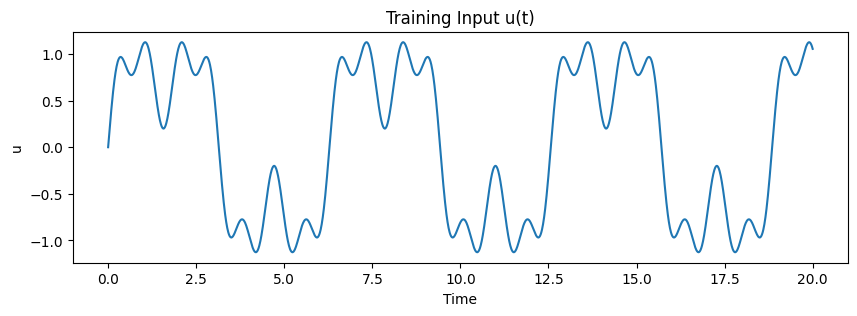

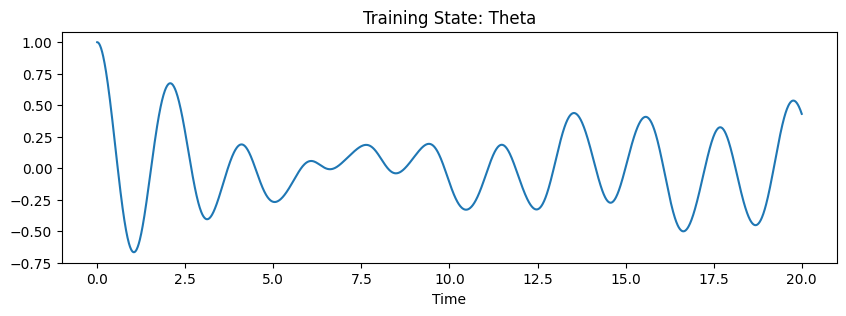

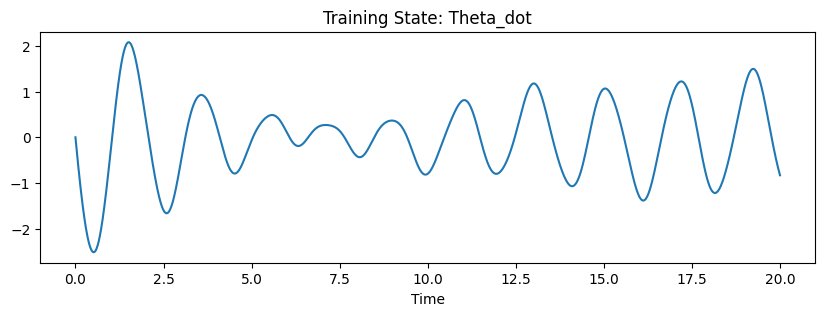

In [5]:
# Plot input and states (training data)
plt.figure(figsize=(10,3))
plt.plot(t_eval, [control(t) for t in t_eval])
plt.title("Training Input u(t)")
plt.xlabel("Time")
plt.ylabel("u")

plt.figure(figsize=(10,3))
plt.plot(t_eval, sol.y[0])
plt.title("Training State: Theta")
plt.xlabel("Time")

plt.figure(figsize=(10,3))
plt.plot(t_eval, sol.y[1])
plt.title("Training State: Theta_dot")
plt.xlabel("Time")

plt.show()

In [6]:

# Build dataset
data = []
for k in range(len(t_eval)-1):
    x = sol.y[:, k]
    x_next = sol.y[:, k+1]
    u = control(t_eval[k])
    data.append([x[0], x[1], u, x_next[0], x_next[1]])

df = pd.DataFrame(data, columns=["theta","theta_dot","u","theta_next","theta_dot_next"])

### Koopman Lifting

We choose nonlinear observables:

$$
z = g(x) = [\theta, \dot{\theta}, \sin(\theta), \cos(\theta), \theta^2, \dot{\theta}^2]^T
$$

In [7]:
def lift(X):
    theta = X[0]
    theta_dot = X[1]
    
    return np.vstack([
        theta,
        theta_dot,
        np.sin(theta),
        np.cos(theta),
        theta**2,
        theta_dot**2
    ])

### Koopman Approximation

We assume:

$$
z_{k+1} = A_d z_k + B_d u_k
$$

Stacking data:

$$
Z_{next} = K \Omega, \quad \Omega = \begin{bmatrix} Z \\ U \end{bmatrix}
$$

Solve:

$$
K = Z_{next} \Omega^\dagger
$$

In [8]:
X = df[["theta","theta_dot"]].values.T
X_next = df[["theta_next","theta_dot_next"]].values.T
U = df[["u"]].values.T

Z = lift(X)
Z_next = lift(X_next)

ZU = np.vstack((Z, U))

K = Z_next @ np.linalg.pinv(ZU)

n = Z.shape[0]
Ad = K[:, :n]
Bd = K[:, n:]

### Continuous Recovery (Block Log Trick)

We form:

$$
M = \begin{bmatrix} A_d & B_d \\ 0 & I \end{bmatrix}
$$

Then:

$$
\frac{1}{dt} \log(M) = \begin{bmatrix} A_c & B_c \\ 0 & 0 \end{bmatrix}
$$

In [9]:
m = Bd.shape[1]

M = np.block([
    [Ad, Bd],
    [np.zeros((m, n)), np.eye(m)]
])

M_log = logm(M) / dt

A_est = M_log[:n, :n]
B_est = M_log[:n, n:]

### Change Time Step

In [10]:
T_test = 20
N_test = 4000

t_eval_test = np.linspace(0, T_test, N_test)
dt_new = t_eval_test[1] - t_eval_test[0]

M_c = np.block([
    [A_est, B_est],
    [np.zeros((m, n)), np.zeros((m, m))]
])

Md = expm(M_c * dt_new)

A_new = Md[:n, :n]
B_new = Md[:n, n:]

### Rollout Prediction

In [11]:
def z_dynamics(z0, A, B, t_eval, ctrl_fun):
    z = z0.reshape(-1,1)
    z_hist = [z.copy()]
    
    for k in range(len(t_eval)-1):
        u = np.array([[ctrl_fun(t_eval[k])]])
        z = A @ z + B @ u
        z_hist.append(z.copy())
    
    return np.hstack(z_hist)

In [12]:
def control_test(t):
    return (
        0.8*np.sin(2*t**2) +          # nonlinear frequency growth
        0.5*np.cos(15*t) +            # high frequency
        0.3*np.sin(40*t) +            # very high frequency
        0.2*np.sign(np.sin(3*t))      # discontinuity (hard test)
    )

### Validation

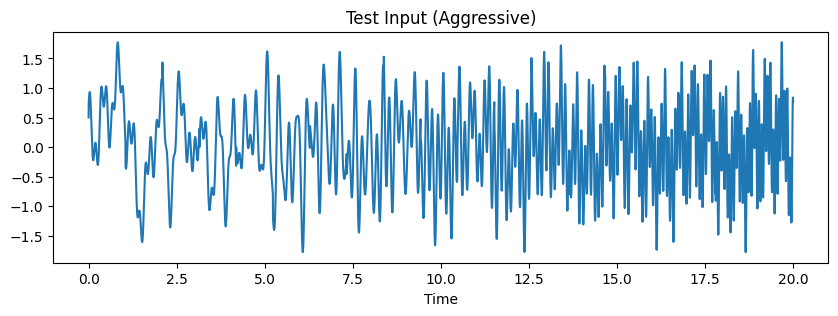

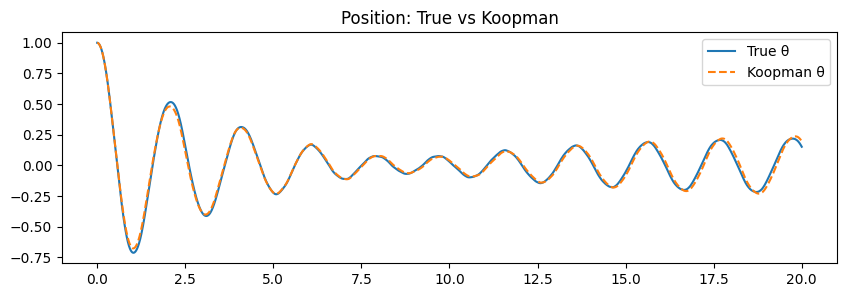

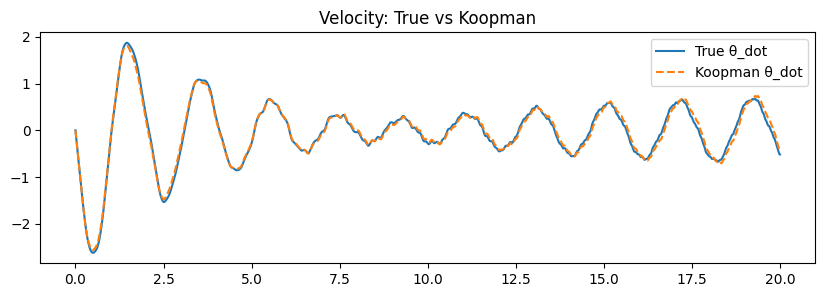

In [13]:
# True system
sol_true = solve_ivp(
    dynamics, 
    [0, T_test], 
    x0, 
    t_eval=t_eval_test, 
    args=(control_test,)
)

# Koopman rollout
z0 = lift(x0.reshape(2,1))
z_pred = z_dynamics(z0, A_new, B_new, t_eval_test, control_test)

theta_pred = z_pred[0]
theta_dot_pred = z_pred[1]

# ---- Plot input ----
plt.figure(figsize=(10,3))
u_test = [control_test(t) for t in t_eval_test]
plt.plot(t_eval_test, u_test)
plt.title("Test Input (Aggressive)")
plt.xlabel("Time")

# ---- Position ----
plt.figure(figsize=(10,3))
plt.plot(t_eval_test, sol_true.y[0], label="True θ")
plt.plot(t_eval_test, theta_pred, '--', label="Koopman θ")
plt.legend()
plt.title("Position: True vs Koopman")

# ---- Velocity ----
plt.figure(figsize=(10,3))
plt.plot(t_eval_test, sol_true.y[1], label="True θ_dot")
plt.plot(t_eval_test, theta_dot_pred, '--', label="Koopman θ_dot")
plt.legend()
plt.title("Velocity: True vs Koopman")

plt.show()

### Error quantification

In [14]:
def compute_errors(x_true, x_pred):
    """
    x_true, x_pred: shape (n_states, N)
    """
    error = x_true - x_pred
    
    # RMSE per state
    rmse_per_state = np.sqrt(np.mean(error**2, axis=1))
    
    # Total RMSE
    rmse_total = np.sqrt(np.mean(error**2))
    
    # Time-varying RMSE
    rmse_time = np.sqrt(np.mean(error**2, axis=0))
    
    # Relative error (avoid divide by zero)
    eps = 1e-8
    rel_error = np.abs(error) / (np.abs(x_true) + eps)
    
    return {
        "error": error,
        "rmse_per_state": rmse_per_state,
        "rmse_total": rmse_total,
        "rmse_time": rmse_time,
        "rel_error": rel_error
    }

In [15]:
x_true = sol_true.y
x_pred = np.vstack([theta_pred, theta_dot_pred])

errors = compute_errors(x_true, x_pred)

print("RMSE per state:", errors["rmse_per_state"])
print("Total RMSE:", errors["rmse_total"])

RMSE per state: [0.02124876 0.06491239]
Total RMSE: 0.04829662549671679


##### Point-wise Error

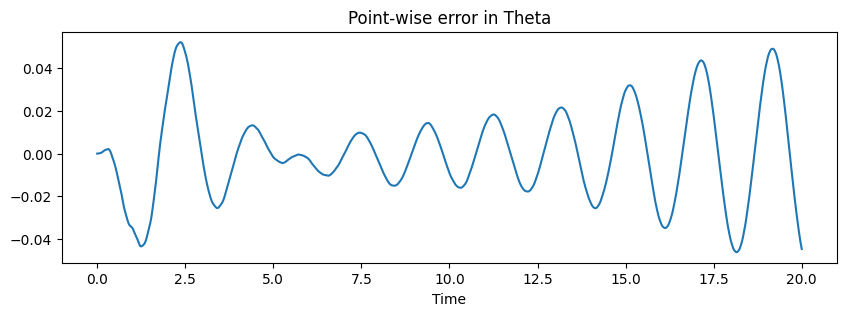

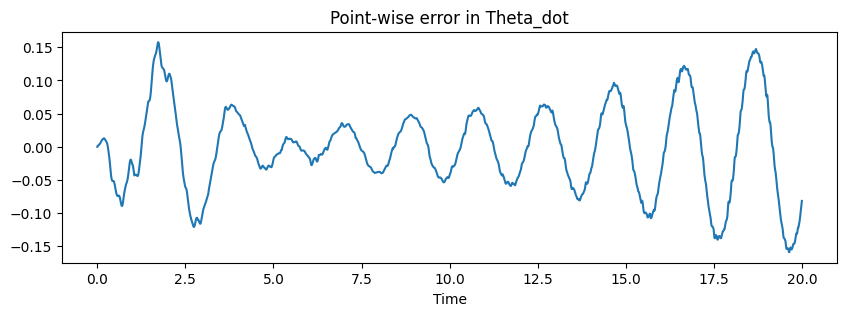

In [16]:
plt.figure(figsize=(10,3))
plt.plot(t_eval_test, errors["error"][0])
plt.title("Point-wise error in Theta")
plt.xlabel("Time")

plt.figure(figsize=(10,3))
plt.plot(t_eval_test, errors["error"][1])
plt.title("Point-wise error in Theta_dot")
plt.xlabel("Time")

plt.show()

##### RSME Error

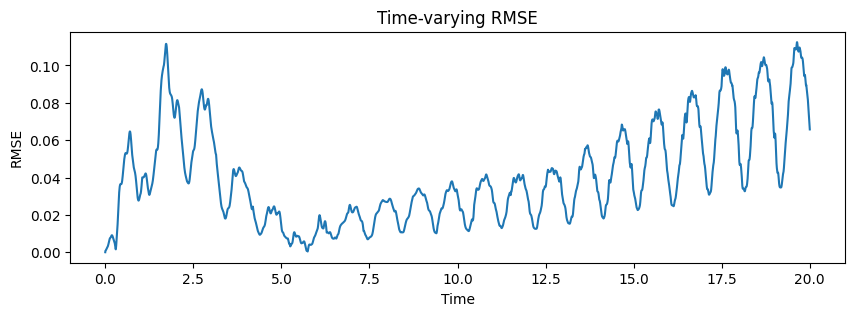

In [17]:
plt.figure(figsize=(10,3))
plt.plot(t_eval_test, errors["rmse_time"])
plt.title("Time-varying RMSE")
plt.xlabel("Time")
plt.ylabel("RMSE")
plt.show()

##### Relative Error

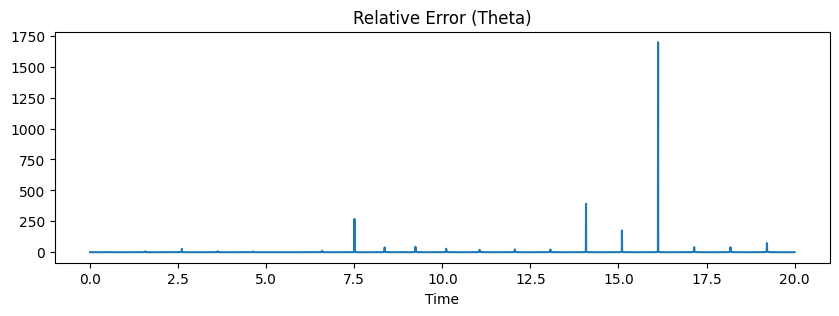

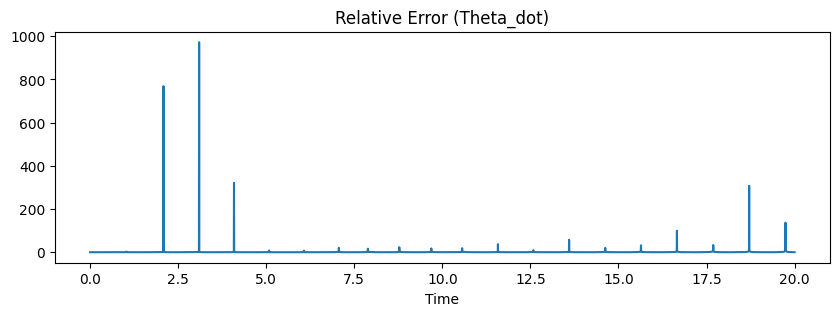

In [23]:
plt.figure(figsize=(10,3))
plt.plot(t_eval_test, errors["rel_error"][0])
plt.title("Relative Error (Theta)")
plt.xlabel("Time")

plt.figure(figsize=(10,3))
plt.plot(t_eval_test, errors["rel_error"][1])
plt.title("Relative Error (Theta_dot)")
plt.xlabel("Time")
plt.show()

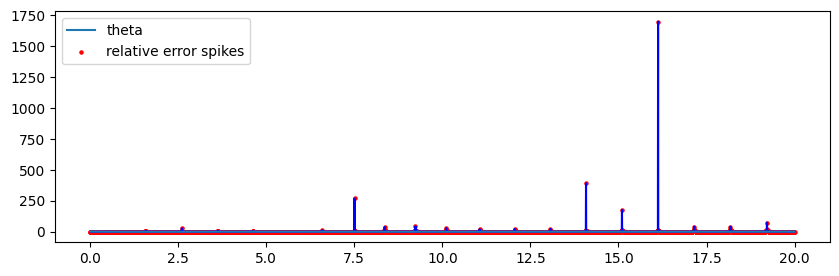

In [29]:
# The relative error spikes are mostly because when X_ture goes to zero relative error measure fails! 
plt.figure(figsize=(10,3))
plt.plot(t_eval_test, errors["rel_error"][0], color="b")
plt.plot(t_eval_test, x_true[0], label="theta")
plt.scatter(
    t_eval_test,
    errors["rel_error"][0],
    s=5,
    color='red',
    label="relative error spikes"
)
plt.legend()